### Routing

当系统不只有一个数据库时，路由决定了用户的问题应该去哪里寻找答案

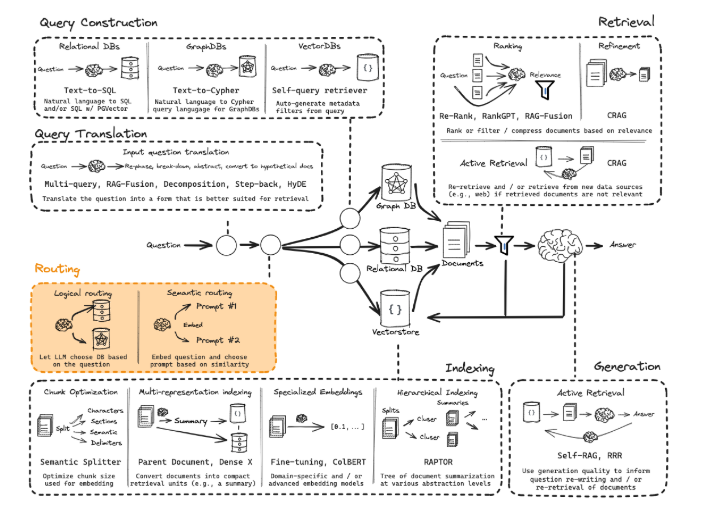

#### 一、逻辑路由
- 核心理念：让大模型像分类器一样，根据推理能力决定该使用哪个数据源
- 工作原理：预先给 LLM 定义好几种可选的数据库或路径，并描述它们各自的用途。LLM 会分析用户的问题，然后输出一个结构化的对象（如 JSON），指引系统走向正确的路径
- 技术手段：通常通过函数调用活结构化输出来实现，将输出严格限制在预设的几个选项中

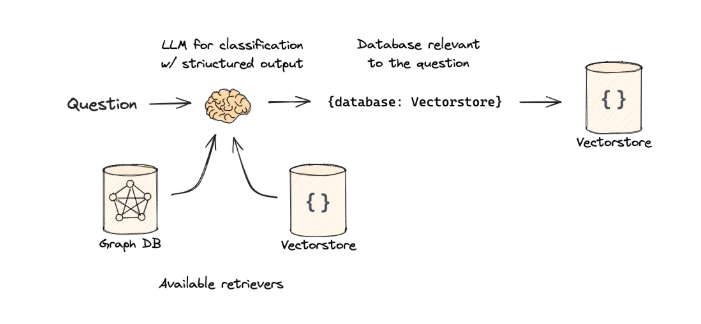

In [1]:
import os
from typing import Literal

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from pydantic import BaseModel, Field
from langchain_community.chat_models.tongyi import ChatTongyi

# 设置 API Key
DASHSCOPE_API_KEY = "sk-bb5a3bc665be4d35bea3efce0196c8c1"
os.environ["DASHSCOPE_API_KEY"] = DASHSCOPE_API_KEY

# 模型配置
LLM_MODEL = "qwen-turbo"
TEMPERATURE = 0.0

# 初始化通义千问模型
llm = ChatTongyi(
    model=LLM_MODEL,
    temperature=TEMPERATURE,
    dashscope_api_key=DASHSCOPE_API_KEY
)


c:\Users\23017\anaconda3\envs\rag_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 定义数据模型
class RouteQuery(BaseModel):
    """Route a user query to the most relevant datasource"""
    datasource: Literal["python_docs", "js_docs", "golang_docs"] = Field(
        ...,
        description="Given a user question choose which datasource would be most relevant for answering their question",
    )

# 创建输出解析器
parser = PydanticOutputParser(pydantic_object=RouteQuery)
prompt = PromptTemplate(
    template="""You are an expert at routing a user question to the appropriate data source.
Based on the programming language the question is referring to, route it to one of: python_docs, js_docs, golang_docs.

Question: {question}

{format_instructions}
""",
    input_variables=["question"],
    partial_variables={"format_instructions": parser.get_format_instructions()}
)

# 构建处理链：提示词 -> 大模型 -> 解析器
router = prompt | llm | parser
question = """Why doesn't the following code work:

from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(["human", "speak in {language}"])
prompt.invoke("french")
"""
try:
    result = router.invoke({"question": question})
    print("路由结果:", result)
    # 可以直接访问结果字段
    print("数据源:", result.datasource)
except Exception as e:
    print("处理失败:", e)

路由结果: datasource='python_docs'
数据源: python_docs


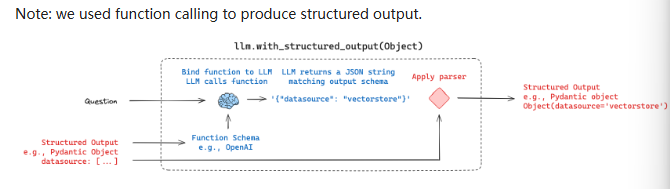

In [3]:
def choose_route(result):
  if "python_docs" in result.datasource.lower():
    return "chain of python_docs"
  elif "js_docs" in result.datasource.lower():
    return "chain of js_docs"
  else:
    return "chain of golang_docs"
  
from langchain_core.runnables import RunnableLambda
full_chain = router | RunnableLambda(choose_route) 
result = full_chain.invoke({"question": question})
print(result)



chain of python_docs


#### 二、语义路由
不依赖LLM的推理，而是利用向量相似度来决定路径
- 工作原理：将不同的”路径描述“先转换为向量。当用户提出问题时，也将问题向量化，然后计算它与哪个路径的 Prompt 最接近
- 应用场景：比如预设一个“数学提示词”向量和一个“物理提示词”向量

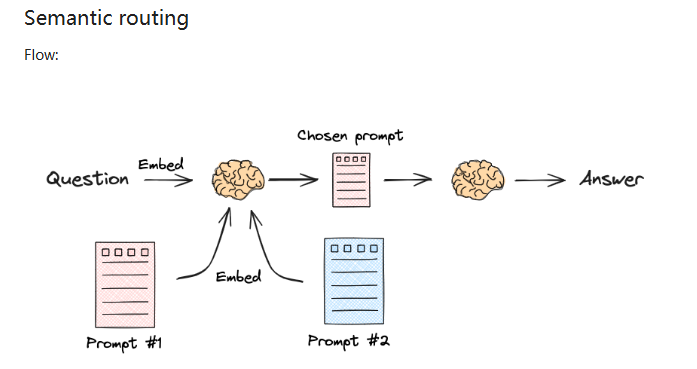

In [24]:

from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_community.chat_models.tongyi import ChatTongyi
import numpy as np

In [25]:

def cosine_similarity(X, Y):
    """计算两个向量或矩阵之间的余弦相似度"""
   
    X = np.array(X)
    Y = np.array(Y)
    # 归一化
    X_norm = X / np.linalg.norm(X, axis=-1, keepdims=True)
    Y_norm = Y / np.linalg.norm(Y, axis=-1, keepdims=True)
    # 计算点积
    return np.dot(X_norm, Y_norm.T)

In [26]:
# Two prompts
physics_template = """You are a very smart physics professor. \
You are great at answering questions about physics in a concise and easy to understand manner. \
When you don't know the answer to a question you admit that you don't know.

Here is a question:
{query}"""

math_template = """You are a very good mathematician. You are great at answering math questions. \
You are so good because you are able to break down hard problems into their component parts, \
answer the component parts, and then put them together to answer the broader question.

Here is a question:
{query}"""

In [27]:
# Embed prompts
EMBEDDING_MODEL = "all-MiniLM-L6-v2"  # 免费嵌入模型
embeddings = HuggingFaceEmbeddings(
    model_name=EMBEDDING_MODEL,
    model_kwargs={"device": "cpu"},  # 仅用CPU，无需GPU
    encode_kwargs={"normalize_embeddings": True}  # 归一化向量，提升检索精度
)
prompt_templates = [physics_template, math_template]
prompt_embeddings = embeddings.embed_documents(prompt_templates)

# Route question to prompt 
def prompt_router(input):
    # Embed question
    query_embedding = embeddings.embed_query(input["query"])
    # Compute similarity
    similarity = cosine_similarity([query_embedding], prompt_embeddings)[0]
    most_similar = prompt_templates[similarity.argmax()]
    # Chosen prompt 
    print("Using MATH" if most_similar == math_template else "Using PHYSICS")
    return PromptTemplate.from_template(most_similar)


chain = (
    {"query": RunnablePassthrough()}
    | RunnableLambda(prompt_router)
    | llm
    | StrOutputParser()
)

print(chain.invoke("What's a black hole"))

C:\Users\23017\AppData\Local\Temp\ipykernel_33292\3930451721.py:3: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1013.84it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Using PHYSICS
A black hole is a region in space where the gravitational pull is so strong that nothing—not even light—can escape from it. It forms when a massive star collapses under its own gravity at the end of its life. The core of the star becomes incredibly dense, creating a point of infinite density called a singularity, surrounded by an event horizon, which is the boundary beyond which nothing can return.


#### 三、路由的重要性
1. 多数据源管理：你可以将问题分流到向量库（查非结构化文档）、SQL（查结构化数据）或图数据库（查关系）。
2. 效率与精准度：避免在无关的数据库中“盲目搜索”，不仅节省了 token 和时间，还能减少无关信息带来的噪音。
3. 专业化处理：不同的路由路径可以对应不同的提示词（Prompt）或处理逻辑，使回复更专业